# [Issue \#1452](https://github.com/JetBrains/lets-plot/issues/1452) Workaround

In [1]:
import numpy as np
import pandas as pd

from lets_plot import *


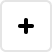
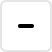
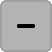
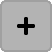
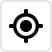
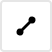
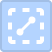
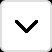
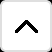
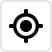
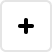
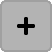
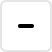
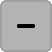
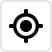
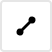
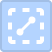
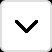
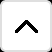
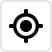

In [2]:
LetsPlot.setup_html()

## Dataset

In [3]:
df = pd.DataFrame({
    "coord": [0, 20, 40, 60],
    "area": [3.14, 12.57, 50.27, 201.06]
})

## Solution 1: `scale_size(range=..., trans=...)`

In [7]:
range_min = 2 * np.sqrt(df["area"].min()) / np.sqrt(np.pi)
range_max = 2 * np.sqrt(df["area"].max()) / np.sqrt(np.pi)

p = ggplot(df, aes(y="coord", size="area")) + \
    geom_point(size_unit='y')

gggrid([
    p + scale_size(range=[2, 16]) + ggtitle("Default scale"),
    p + scale_size(range=[range_min, range_max], trans='sqrt') + ggtitle("scale_size() with range and trans")
]) + ggtb()

## Solution 2: `scale_identity('size')`

In [5]:
df["diameter"] = 2 * np.sqrt(df["area"] / np.pi)

gggrid([
    ggplot(df, aes(y="coord", size="area")) + \
        geom_point(size_unit='y') + \
        ggtitle("Default scale, size='area'"),
    ggplot(df, aes(y="coord", size="diameter")) + \
        geom_point(size_unit='y') + \
        scale_identity('size') + \
        ggtitle("scale_identity(), size='diameter'")
]) + ggtb()